In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/projects/clv

/content/drive/MyDrive/projects/clv


In [ ]:
pip install lifetimes

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy.stats import kruskal

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, StratifiedKFold
)
from xgboost import XGBRegressor, XGBClassifier

from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import (
    plot_frequency_recency_matrix,
    plot_probability_alive_matrix,
    plot_period_transactions
)

import shap


print(' All libraries loaded.')

 All libraries loaded.


## Section 1 - EDA & Data Quality


In [ ]:
df_09  = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_10  = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
df_raw = pd.concat([df_09, df_10], ignore_index=True)

print(f'Combined raw shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

Combined raw shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [ ]:
# Missing value audit
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print('Missing Values')
print(pd.DataFrame({'count': missing, '%': missing_pct}).query('count > 0'))


Missing Values
              count      %
Description    4382   0.41
Customer ID  243007  22.77


In [ ]:
# 1: drop missing Customer ID
#anonymous transactions are unusable
n0 = len(df_raw)
df = df_raw.dropna(subset=['Customer ID']).copy()
print(f'\nStep 1 : Dropped {n0-len(df):,} rows with missing Customer ID ({(n0-len(df))/n0*100:.1f}%)')



Step 1 : Dropped 243,007 rows with missing Customer ID (22.8%)


In [ ]:
# 2: parse types
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)

In [ ]:
df.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom


In [ ]:
# 3: remove returns
# (Invoice starting with C) reverse purchases -> not real spend ?
l = len(df)
returns = df['Invoice'].astype(str).str.startswith('C')
df = df[~returns].copy()
print(f'\n S3: Dropped {l-len(df):,} rows with returns ({(l-len(df))/l*100:.1f}%)')




 S3: Dropped 0 rows with returns (0.0%)


In [ ]:
# 4: remove non-positive quantity & price
# Zero/negative values are adjustments or errors
l2 = len(df)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy()
print(f'Step 3: Removed {l2-len(df):,} rows with non-positive Quantity or Price')


Step 3: Removed 18,815 rows with non-positive Quantity or Price


In [ ]:
df['order_value'] = df['Quantity'] * df['Price']
snapshot = df['InvoiceDate'].max()

In [ ]:
print(f'\nClean dataset: {len(df):,} rows - {df["Customer ID"].nunique():,} customers')
print(f'Date range: {df["InvoiceDate"].min().date()} → {snapshot.date()}')
print(f'Total revenue: £{df["order_value"].sum():,.0f}')


Clean dataset: 805,549 rows - 5,878 customers
Date range: 2009-12-01 → 2011-12-09
Total revenue: £17,743,429


In [ ]:
#df_raw upload to csv file
df.to_csv('df.csv', index=False)

### EDA- Wholesale Customer Detection

Online Retail II contains both **retail customers** (individuals, small orders)
and **wholesale customers** (businesses, large bulk orders).

**Why separation matters for CLV:**
BG/NBD assumes a relatively homogeneous customer population where all customers
share the same underlying purchase rate and dropout distributions.
Wholesale customers violate this. (their behaviour (large infrequent orders)
is structurally different from retail).


**Detection method: IQR-based multivariate outlier detection (3× IQR)**
- More principled than a hard percentile cutoff (which is arbitrary)
- Uses both average order value AND average quantity
- 3× IQR = extreme outliers only — conservative, avoids over-removal

In [ ]:
# Customer-level summary
cust_summary = (
    df.groupby('Customer ID')
    .agg(
        avg_order_value=('order_value', 'mean'),
        avg_quantity   =('Quantity',    'mean'),
        total_spend    =('order_value', 'sum'),
        n_invoices     =('Invoice',     'nunique')
    )
    .reset_index()
)

def iqr_upper(series, k=3):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75) #25th and 75th percentile of the data.
    return Q3 + k * (Q3 - Q1) # Q3 - Q1  Interquartile Range (IQR)  --- k=3 is a common heuristic for identifying extreme outliers
    # return upper bound threshold

val_thresh = iqr_upper(cust_summary['avg_order_value'])
qty_thresh = iqr_upper(cust_summary['avg_quantity'])

cust_summary['is_wholesale'] = (
    (cust_summary['avg_order_value'] > val_thresh) |
    (cust_summary['avg_quantity']    > qty_thresh)
)

n_wholesale  = cust_summary['is_wholesale'].sum()
n_retail     = (~cust_summary['is_wholesale']).sum()
rev_wholesale = cust_summary[cust_summary['is_wholesale']]['total_spend'].sum()
rev_total     = cust_summary['total_spend'].sum()

print('** Wholesale Detection Results **')
print(f'Avg order value threshold (3× IQR): {val_thresh:.2f}')
print(f'Avg quantity threshold    (3× IQR): {qty_thresh:.0f} items')
print(f'\nRetail customers:    {n_retail:,}  ({n_retail/(n_retail+n_wholesale)*100:.1f}%)')
print(f'Wholesale customers: {n_wholesale:,}  ({n_wholesale/(n_retail+n_wholesale)*100:.1f}%)')
print(f'Wholesale revenue share: {rev_wholesale/rev_total*100:.1f}%')


retail_ids = set(cust_summary[~cust_summary['is_wholesale']]['Customer ID'])
df_retail  = df[df['Customer ID'].isin(retail_ids)].copy()
print(f'\nRetail dataset: {len(df_retail):,} transactions, {df_retail["Customer ID"].nunique():,} customers')

** Wholesale Detection Results **
Avg order value threshold (3× IQR): 62.37
Avg quantity threshold    (3× IQR): 40 items

Retail customers:    5,384  (91.6%)
Wholesale customers: 494  (8.4%)
Wholesale revenue share: 33.0%

Retail dataset: 766,374 transactions, 5,384 customers


### EDA: Revenue & Behaviour Patterns

** Transaction Value Statistics (retail) **
  Mean:     15.51
  Median:   10.50
  Std:      24.37
  Skewness: 28.370 -- most of the transaction values are concentrated on the lower end(a heavily skewed distribution)
  Kurtosis: 3120.087
  P95:      44.25
  P99:      102.00


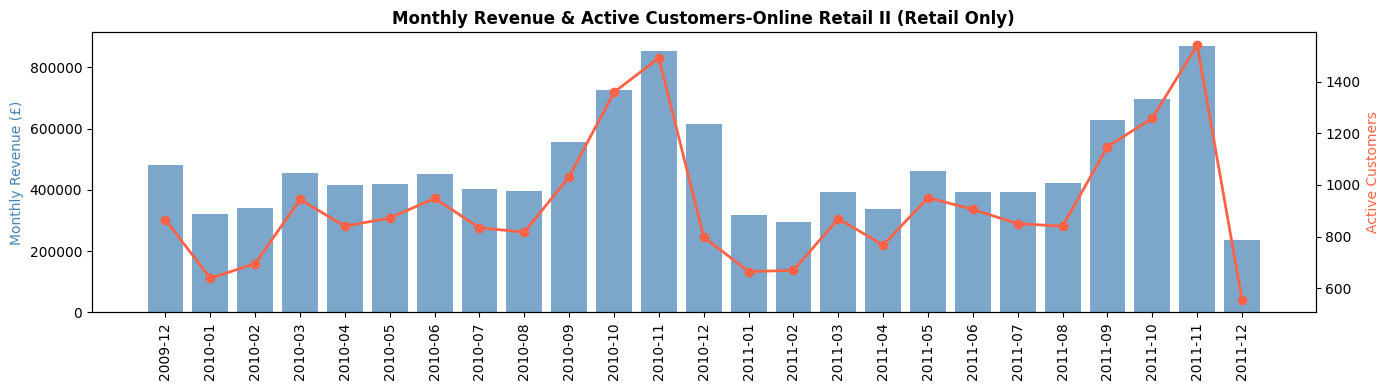

In [ ]:
# Revenue statistics
rev = df_retail['order_value']
print('** Transaction Value Statistics (retail) **')
print(f'  Mean:     {rev.mean():.2f}')
print(f'  Median:   {rev.median():.2f}')
print(f'  Std:      {rev.std():.2f}')
print(f'  Skewness: {rev.skew():.3f} -- most of the transaction values are concentrated on the lower end(a heavily skewed distribution)')
# 0 for normal distribution
print(f'  Kurtosis: {rev.kurtosis():.3f}')
# 3 for normal disrtibutions-- 0 in pandas
print(f'  P95:      {rev.quantile(0.95):.2f}')
print(f'  P99:      {rev.quantile(0.99):.2f}')

df_retail['month'] = df_retail['InvoiceDate'].dt.to_period('M')
monthly = (
    df_retail.groupby('month')
    .agg(revenue=('order_value','sum'),
         n_orders=('Invoice','nunique'),
         n_customers=('Customer ID','nunique'))
    .reset_index()
)
monthly['month_str'] = monthly['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(monthly['month_str'], monthly['revenue'], color='steelblue', alpha=0.7)
ax2.plot(monthly['month_str'], monthly['n_customers'], color='tomato',
         linewidth=2, marker='o')
ax1.set_ylabel('Monthly Revenue (£)', color='steelblue')
ax2.set_ylabel('Active Customers', color='tomato')
ax1.set_xticklabels(monthly['month_str'], rotation=90)
plt.title('Monthly Revenue & Active Customers-Online Retail II (Retail Only)',
          fontweight='bold')
plt.tight_layout()
plt.show()

** Repeat Purchase Analysis **
  Customers with > 1 order:  72.9%
  Median orders/customer:    3.0
  Mean orders/customer:      6.0
  Max orders/customer:       398

Dataset suitability check:
  Repeat rate 73% > 20% minimum       →  BG/NBD justified
  Median frequency 3 > 2


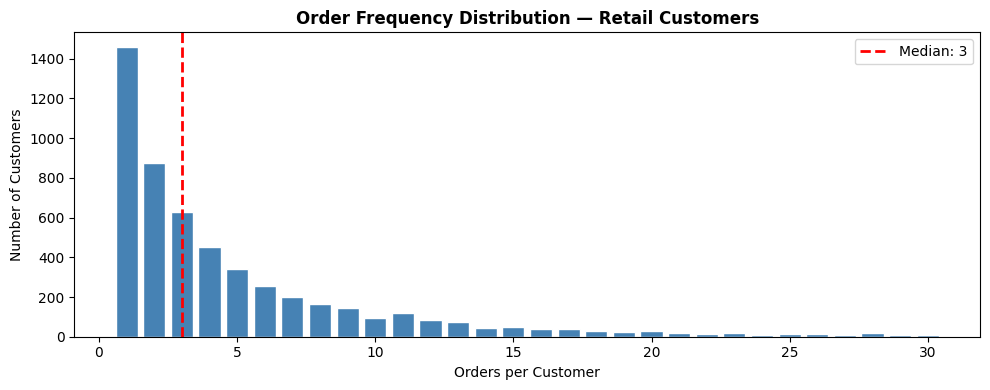

In [ ]:
# Repeat purchase rate - validates dataset suitability
order_counts = df_retail.groupby('Customer ID')['Invoice'].nunique()

repeat_rate = (order_counts > 1).mean() * 100
median_freq  = order_counts.median()
mean_freq    = order_counts.mean()

print('** Repeat Purchase Analysis **')
print(f'  Customers with > 1 order:  {repeat_rate:.1f}%')
print(f'  Median orders/customer:    {median_freq:.1f}')
print(f'  Mean orders/customer:      {mean_freq:.1f}')
print(f'  Max orders/customer:       {order_counts.max()}')
print()
print('Dataset suitability check:')
print(f'  Repeat rate {repeat_rate:.0f}% > 20% minimum       →  BG/NBD justified')
print(f'  Median frequency {median_freq:.0f} > 2')


fig, ax = plt.subplots(figsize=(10, 4))
freq_dist = order_counts.value_counts().sort_index().head(30)
ax.bar(freq_dist.index, freq_dist.values, color='steelblue', edgecolor='white')
ax.axvline(median_freq, color='red', linestyle='--', linewidth=2,
           label=f'Median: {median_freq:.0f}')
ax.set_xlabel('Orders per Customer')
ax.set_ylabel('Number of Customers')
ax.set_title('Order Frequency Distribution — Retail Customers', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Section 2 - Descriptive CLV

### Statistical Context

Descriptive CLV answers: *"What has this customer been worth historically?"*
It does not predict future value
Its purpose is to establish benchmarks and validate that probabilistic
and ML models produce sensible results.

**Key design decision / churn definition:**
we can define churn as "fewer than (for example 2 visits" without justification.
but We use a **data-driven definition**: a customer is churned if their last purchase
was more than 2× their average inter-purchase interval ago.
This is defensible, dataset-specific, and fully documented.

In [ ]:
# Customer-level aggregation
PROFIT_MARGIN            = 0.15   # 15%
CUSTOMER_LIFESPAN_YEARS  = 3      # conservative
total_days  = (df_retail['InvoiceDate'].max() - df_retail['InvoiceDate'].min()).days
total_years = total_days / 365

cust_agg = (
    df_retail.groupby('Customer ID')
    .agg(
        first_purchase  =('InvoiceDate', 'min'),
        last_purchase   =('InvoiceDate', 'max'),
        n_orders        =('Invoice',     'nunique'),
        total_spend     =('order_value', 'sum'),
        avg_order_value =('order_value', 'mean')
    )
    .reset_index()
)
cust_agg['days_since_last']  = (snapshot - cust_agg['last_purchase']).dt.days
cust_agg['observation_days'] = (cust_agg['last_purchase'] - cust_agg['first_purchase']).dt.days

# churn definition
cust_agg['avg_interpurchase'] = np.where(
    cust_agg['n_orders'] > 1,
    cust_agg['observation_days'] / (cust_agg['n_orders'] - 1), #for 2 orders, there is 1 interval between them. to calculate average length of each of these intervals.
    total_days
)
cust_agg['is_churned'] = cust_agg['days_since_last'] > (cust_agg['avg_interpurchase'] * 2)

churn_rate         = cust_agg['is_churned'].mean()
avg_purchase_value = cust_agg['avg_order_value'].mean()
avg_freq_yr        = (cust_agg['n_orders'] / total_years).mean()

print('** Aggregated Descriptive Statistics **')
print(f'  Observation period:           {total_years:.2f} years ({total_days} days)')
print(f'  Total customers:              {len(cust_agg):,}')
print(f'  Avg purchase value:           {avg_purchase_value:.2f}')
print(f'  Avg purchase frequency/year:  {avg_freq_yr:.1f} orders')
print(f'  Churn rate (data-driven):     {churn_rate*100:.1f}%')
print(f'  Assumed lifespan:             {CUSTOMER_LIFESPAN_YEARS} years')
print(f'  Assumed profit margin:        {PROFIT_MARGIN*100:.0f}%')
print()
print('Churn definition: churned if days_since_last > 2 × avg_interpurchase_interval')
print('This is data-driven - not an arbitrary threshold.')

** Aggregated Descriptive Statistics **
  Observation period:           2.02 years (738 days)
  Total customers:              5,384
  Avg purchase value:           17.82
  Avg purchase frequency/year:  3.0 orders
  Churn rate (data-driven):     20.7%
  Assumed lifespan:             3 years
  Assumed profit margin:        15%

Churn definition: churned if days_since_last > 2 × avg_interpurchase_interval
This is data-driven - not an arbitrary threshold.


In [ ]:
# -CLV calculations - Aggregation Models to establish a baseline CLV
eps = 1e-4

clv_lifetime        = avg_purchase_value * avg_freq_yr * CUSTOMER_LIFESPAN_YEARS
clv_lifetime_profit = clv_lifetime * PROFIT_MARGIN

clv_churn           = (avg_purchase_value * avg_freq_yr) / (churn_rate + eps)
clv_churn_profit    = clv_churn * PROFIT_MARGIN

print('** Aggregated CLV - Two Methods **')
print()
print(f'  Lifetime method  (revenue): {clv_lifetime:,.2f}')
print(f'  Lifetime method  (profit):  {clv_lifetime_profit:,.2f} -- preferred')
print()
print(f'  Churn method     (revenue): {clv_churn:,.2f}')
print(f'  Churn method     (profit):  {clv_churn_profit:,.2f}')
print()
print('   These are population averages.')


** Aggregated CLV - Two Methods **

  Lifetime method  (revenue): 158.91
  Lifetime method  (profit):  23.84 -- preferred

  Churn method     (revenue): 256.11
  Churn method     (profit):  38.42

   These are population averages.


**Cohort Models:**  Segmenting customers by their start month to analyze how different groups behave over time, which provides more granularity than a single aggregated number


In [ ]:
cust_agg.head(3).T

,0,1,2
Customer ID,12347,12349,12350
first_purchase,2010-10-31 14:20:00,2010-04-29 13:20:00,2011-02-02 16:01:00
last_purchase,2011-12-07 15:52:00,2011-11-21 09:51:00,2011-02-02 16:01:00
n_orders,8,4,1
total_spend,5633.32,4428.69,334.4
avg_order_value,22.266087,25.3068,19.670588
days_since_last,1,18,309
observation_days,402,570,0
avg_interpurchase,57.428571,190.0,738.0
is_churned,False,False,False


** Cohort CLV Summary **
cohort_str  cohort_size  avg_orders  avg_total_spend  clv_lifetime  churn_rate
   2009-12          865       14.81          5824.82         62.81        0.23
   2010-01          341        7.89          2862.70         31.96        0.31
   2010-02          349        6.53          2474.17         27.50        0.27
   2010-03          400        6.43          2311.08         25.90        0.23
   2010-04          265        5.28          1814.44         22.95        0.22
   2010-05          238        4.49          1416.36         18.51        0.28
   2010-06          251        4.37          1576.93         17.06        0.29
   2010-07          168        5.25          1714.35         19.34        0.27
   2010-08          148        4.68          1589.21         16.35        0.23
   2010-09          214        4.00          1261.27         15.72        0.24
   2010-10          355        3.60          1193.22         13.84        0.18
   2010-11          305    

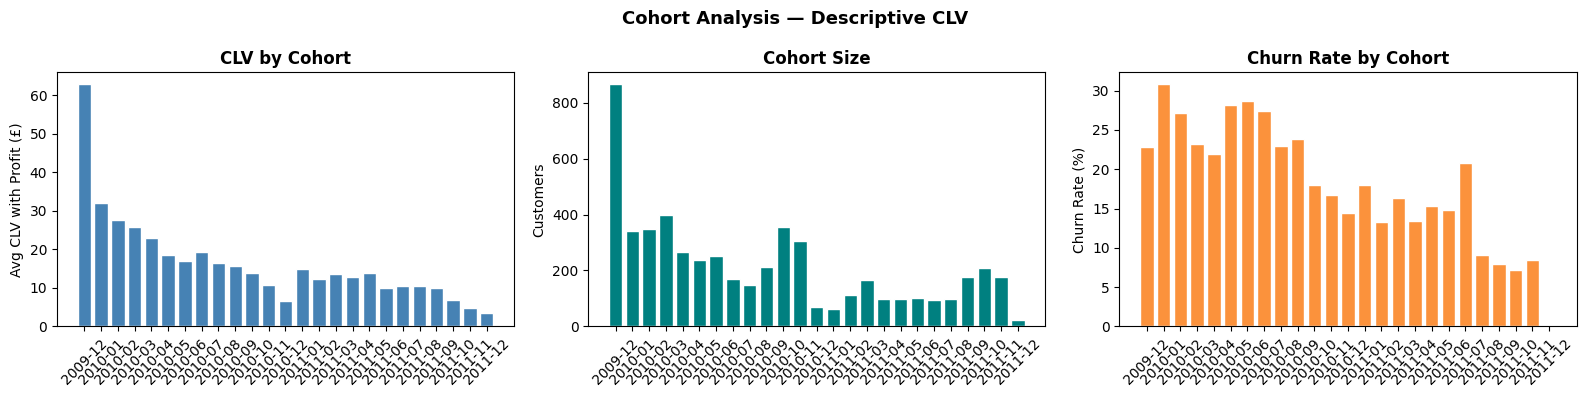


💡 Cohort interpretation:
   Significant CLV variation across cohorts → acquisition quality is changing.
   High CLV + large size = best acquisition periods to replicate. This indicates an effective and scalable acquisition strategy.
   Declining CLV + rising churn = investigate product or pricing changes. This requires a deep dive into product development, pricing strategy, and customer satisfaction metrics.



In [ ]:
#Cohort CLV
cust_agg['cohort'] = cust_agg['first_purchase'].dt.to_period('M')

cohort_clv = (
    cust_agg.groupby('cohort')
    .agg(
        cohort_size    =('Customer ID',    'count'),
        avg_order_value=('avg_order_value','mean'),
        avg_orders     =('n_orders',       'mean'),
        avg_total_spend=('total_spend',    'mean'),
        churn_rate     =('is_churned',     'mean')
    )
    .reset_index()
)
cohort_clv['clv_lifetime'] = (
    cohort_clv['avg_order_value'] *
    (cohort_clv['avg_orders'] / total_years) *
    CUSTOMER_LIFESPAN_YEARS * PROFIT_MARGIN
)
cohort_clv['cohort_str'] = cohort_clv['cohort'].astype(str)

print('** Cohort CLV Summary **')
print(cohort_clv[['cohort_str','cohort_size','avg_orders',
                    'avg_total_spend','clv_lifetime','churn_rate']].round(2).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(cohort_clv['cohort_str'], cohort_clv['clv_lifetime'],
            color='steelblue', edgecolor='white')
axes[0].set_title('CLV by Cohort', fontweight='bold')
axes[0].set_ylabel('Avg CLV with Profit (£)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].bar(cohort_clv['cohort_str'], cohort_clv['cohort_size'],
            color='teal', edgecolor='white')
axes[1].set_title('Cohort Size', fontweight='bold')
axes[1].set_ylabel('Customers')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

axes[2].bar(cohort_clv['cohort_str'], cohort_clv['churn_rate']*100,
            color='#fb923c', edgecolor='white')
axes[2].set_title('Churn Rate by Cohort', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Cohort Analysis — Descriptive CLV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('''
💡 Cohort interpretation:
   Significant CLV variation across cohorts → acquisition quality is changing.
   High CLV + large size = best acquisition periods to replicate. This indicates an effective and scalable acquisition strategy.
   Declining CLV + rising churn = investigate product or pricing changes. This requires a deep dive into product development, pricing strategy, and customer satisfaction metrics.
''')

## Section 3 - RFM Segmentation

** 1-5 Scoring Validation **
Frequency quintile cut points:
  20th percentile: 1.0 orders
  40th percentile: 2.0 orders
  60th percentile: 4.0 orders
  80th percentile: 8.0 orders

 All 4 cut points distinct — 1-5 quintile scoring is justified.


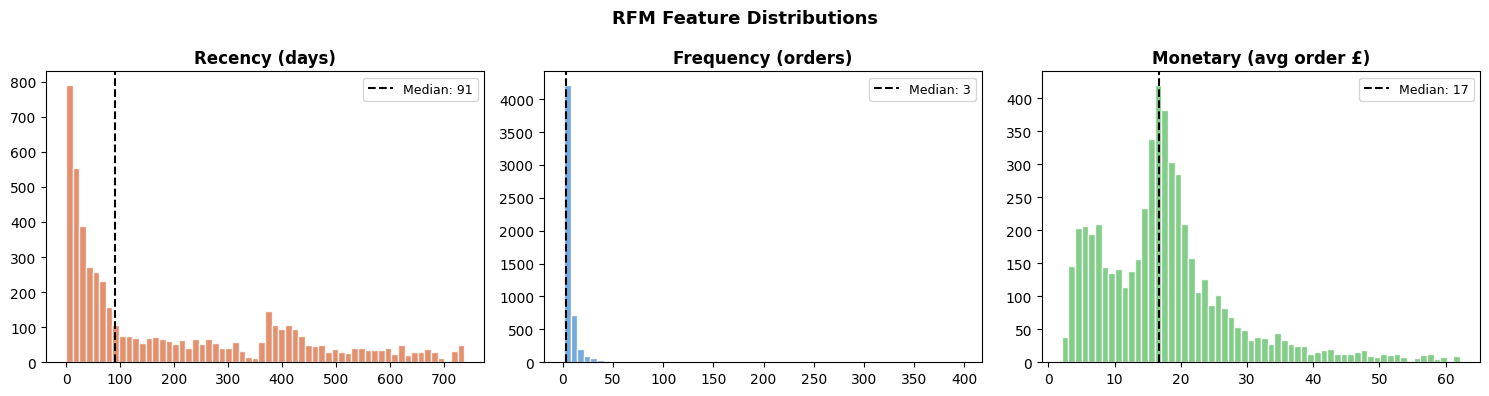


Skewness:
  recency     : +0.905
  frequency   : +14.893
  monetary    : +1.352


In [ ]:
# Build RFM
rfm = (
    df_retail.groupby('Customer ID')
    .agg(
        last_purchase=('InvoiceDate', 'max'),
        frequency    =('Invoice',     'nunique'),
        monetary     =('order_value', 'mean'),
        total_spend  =('order_value', 'sum')
    )
    .reset_index()
)
rfm['recency'] = (snapshot - rfm['last_purchase']).dt.days
rfm = rfm.drop(columns=['last_purchase'])

#  Validate 1-5 scoring
f_cuts = rfm['frequency'].quantile([0.20, 0.40, 0.60, 0.80]).values
print('** 1-5 Scoring Validation **')
print('Frequency quintile cut points:')
for q, v in zip([20,40,60,80], f_cuts):
    print(f'  {q}th percentile: {v:.1f} orders')

n_distinct = len(set(f_cuts))
if n_distinct == 4:
    print('\n All 4 cut points distinct — 1-5 quintile scoring is justified.')

else:
    print(f'\n  Only {n_distinct} distinct cut points — consider 1-3 scoring.')

# Score 1-5
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5,
                           labels=[1,2,3,4,5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=5,
                           labels=[1,2,3,4,5]).astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color, title in zip(
    axes,
    ['recency','frequency','monetary'],
    ['#E07B54','#5E9BD6','#6DC474'],
    ['Recency (days)','Frequency (orders)','Monetary (avg order £)']
):
    ax.hist(rfm[col], bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {rfm[col].median():.0f}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('RFM Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSkewness:')
for col in ['recency','frequency','monetary']:
    print(f'  {col:12s}: {rfm[col].skew():+.3f}')

In [ ]:
rfm

,Customer ID,frequency,monetary,total_spend,recency,r_score,f_score,m_score,rfm_score
0,12347,8,22.266087,5633.32,1,5,4,4,13
1,12349,4,25.306800,4428.69,18,5,3,5,13
2,12350,1,19.670588,334.40,309,2,1,4,7
3,12351,1,14.330000,300.93,374,2,1,2,5
4,12352,10,27.668350,2849.84,35,4,5,5,14
...,...,...,...,...,...,...,...,...,...
5379,18283,22,2.775507,2736.65,3,5,5,1,11
5380,18284,1,16.488571,461.68,431,1,2,3,6
5381,18285,1,35.583333,427.00,660,1,2,5,8
5382,18286,2,19.349701,1296.43,476,1,3,4,8


            segment  n_customers  avg_recency  avg_frequency  avg_monetary  total_revenue  avg_rfm  revenue_%
          Champions          832        18.96          15.02         24.48     5572333.43    13.32       46.9
    Loyal Customers          982        57.34          11.35         13.84     3500789.52    10.63       29.5
            At Risk          632       367.74           4.32         16.32      770645.53     7.74        6.5
Potential Loyalists          650        56.28           3.14         17.19      695077.59     9.81        5.8
        Hibernating         1388       455.15           1.26         16.74      519986.11     5.71        4.4
   Cannot Lose Them          134       327.57           8.15         28.00      441751.08    10.51        3.7
      New Customers          412        26.38           1.48         16.08      202433.11     8.79        1.7
     Need Attention          354       102.67           1.37         19.40      180524.49     7.68        1.5


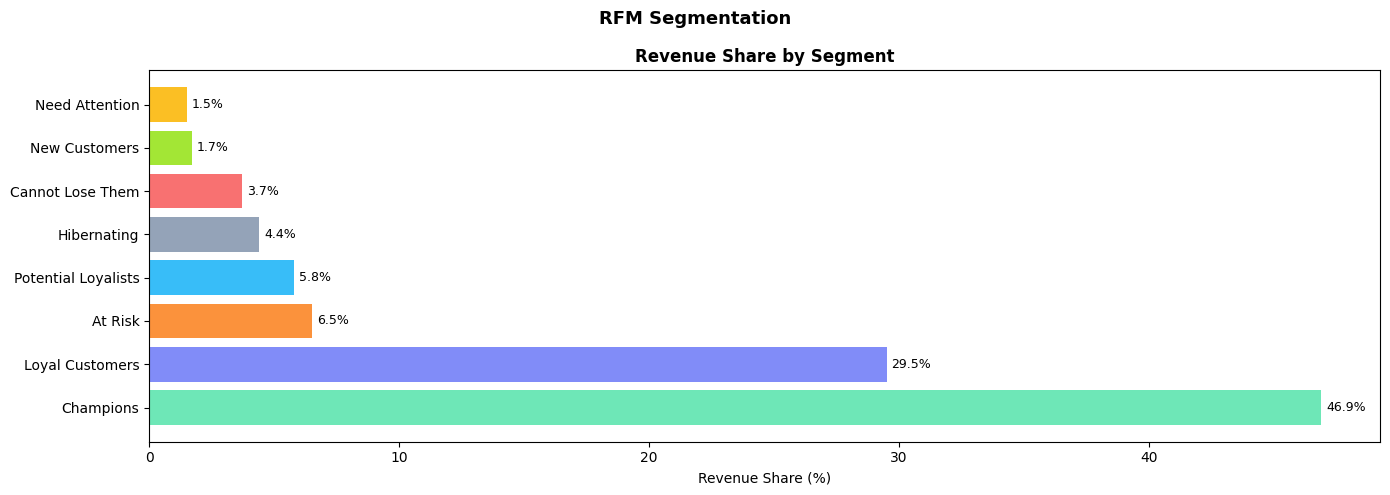

In [ ]:
import matplotlib.pyplot as plt

# Segment assignment
# Cannot Lose Them checked BEFORE At Risk to prevent high-value
# churned customers from being misclassified.

def map_segment(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    if r >= 4 and f >= 4 and m >= 3:
        return 'Champions'
    if f >= 4 and r >= 3:
        return 'Loyal Customers'
    if r >= 3 and f == 3:
        return 'Potential Loyalists'
    if r >= 4 and f <= 2:
        return 'New Customers'
    if r <= 2 and f >= 3:
        return 'At Risk'
    if r <= 2 and f <= 2:
        return 'Hibernating'
    return 'Need Attention'

rfm['segment'] = rfm.apply(map_segment, axis=1)

SEGMENT_COLORS = {
    'Champions':          '#6ee7b7',
    'Loyal Customers':    '#818cf8',
    'Potential Loyalists':'#38bdf8',
    'New Customers':      '#a3e635',
    'Need Attention':     '#fbbf24',
    'At Risk':            '#fb923c',
    'Cannot Lose Them':   '#f87171',
    'Hibernating':        '#94a3b8',
}

seg_stats = (
    rfm.groupby('segment')
    .agg(n_customers=('Customer ID','count'),
         avg_recency=('recency','mean'),
         avg_frequency=('frequency','mean'),
         avg_monetary=('monetary','mean'),
         total_revenue=('total_spend','sum'),
         avg_rfm=('rfm_score','mean'))
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
seg_stats['revenue_%'] = (seg_stats['total_revenue']/seg_stats['total_revenue'].sum()*100).round(1)
print(seg_stats.round(2).to_string(index=False))

fig, axes = plt.subplots(1, figsize=(14, 5))
colors = [SEGMENT_COLORS.get(s,'#64748b') for s in seg_stats['segment']]
axes.barh(seg_stats['segment'], seg_stats['revenue_%'], color=colors)
for i, v in enumerate(seg_stats['revenue_%']):
    axes.text(v+0.2, i, f'{v}%', va='center', fontsize=9)
axes.set_xlabel('Revenue Share (%)')
axes.set_title('Revenue Share by Segment', fontweight='bold')
fig.suptitle('RFM Segmentation', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

### 3.1 - Clustering

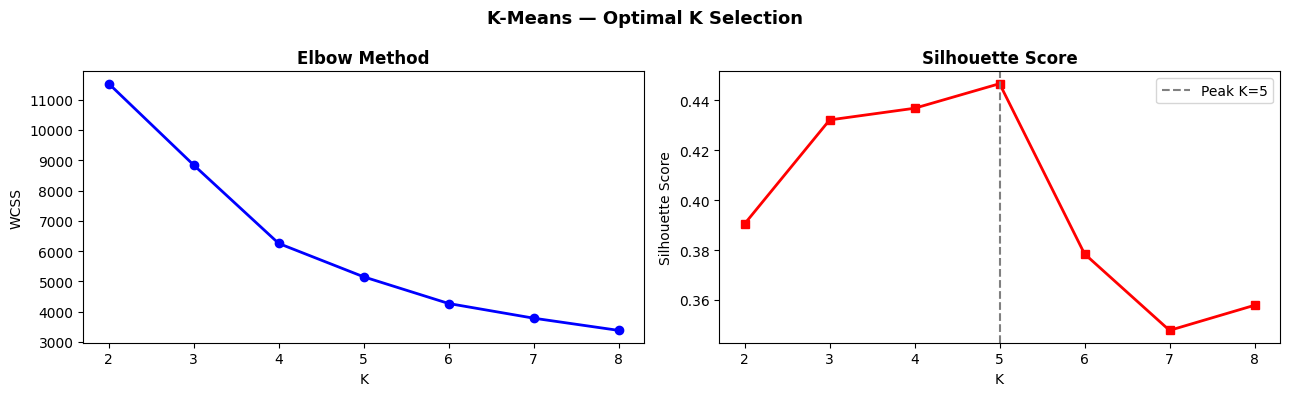

Silhouette peaks at K=5

Design decision:
  Silhouette often peaks at K=2 on RFM data (bimodal: active vs inactive).
  K=2 is statistically cleanest but not actionable for marketing.


In [ ]:
# Used for: CLV prediction features, cluster validation
# Standardise for clustering
X_rfm    = rfm[['recency','frequency','monetary']].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

# K-Means: Elbow + Silhouette
K_range   = range(2, 9)
wcss_list = []
sil_list  = []

for k in K_range:
    km     = KMeans(n_clusters=k, n_init=15, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled, labels,
                                      sample_size=min(5000,len(X_scaled)),
                                      random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_range), wcss_list, 'bo-', linewidth=2)
axes[0].set_xlabel('K'); axes[0].set_ylabel('WCSS')
axes[0].set_title('Elbow Method', fontweight='bold')

best_k_sil = list(K_range)[sil_list.index(max(sil_list))]
axes[1].plot(list(K_range), sil_list, 'rs-', linewidth=2)
axes[1].axvline(best_k_sil, color='gray', linestyle='--',
                 label=f'Peak K={best_k_sil}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].legend()

plt.suptitle('K-Means — Optimal K Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Silhouette peaks at K={best_k_sil}')
print()
print('Design decision:')
print('  Silhouette often peaks at K=2 on RFM data (bimodal: active vs inactive).')
print('  K=2 is statistically cleanest but not actionable for marketing.')


In [ ]:
# k=4 or 5?
#the 'best' K often depends on the specific business context and how easily the resulting segments can be translated into targeted strategies
OPTIMAL_K = 4
km_final  = KMeans(n_clusters=OPTIMAL_K, n_init=20, max_iter=500, random_state=42)
rfm['km_cluster'] = km_final.fit_predict(X_scaled)

km_profile = rfm.groupby('km_cluster')['rfm_score'].mean().sort_values(ascending=False)
km_labels  = {km_profile.index[i]: name for i, name in
              enumerate(['High Value','Mid-High','Mid-Low','Low Value'])}
rfm['km_label'] = rfm['km_cluster'].map(km_labels)

sil_k4 = silhouette_score(X_scaled, rfm['km_cluster'])
ch_k4  = calinski_harabasz_score(X_scaled, rfm['km_cluster'])
db_k4  = davies_bouldin_score(X_scaled, rfm['km_cluster'])

print(f'** K-Means Final Metrics (K=4) **')
print(f'  Silhouette:         {sil_k4:.4f}  (higher = better, range -1 to +1)')
print()
print(rfm.groupby('km_label')[['recency','frequency','monetary','rfm_score']]
      .mean().round(2).sort_values('rfm_score', ascending=False))

** K-Means Final Metrics (K=4) **
  Silhouette:         0.4343  (higher = better, range -1 to +1)

            recency  frequency  monetary  rfm_score
km_label                                           
High Value    42.11     215.67     19.28      12.89
Mid-High     153.29       8.69     39.11      11.58
Mid-Low       65.24       6.89     15.01      10.01
Low Value    464.38       2.17     14.88       6.10


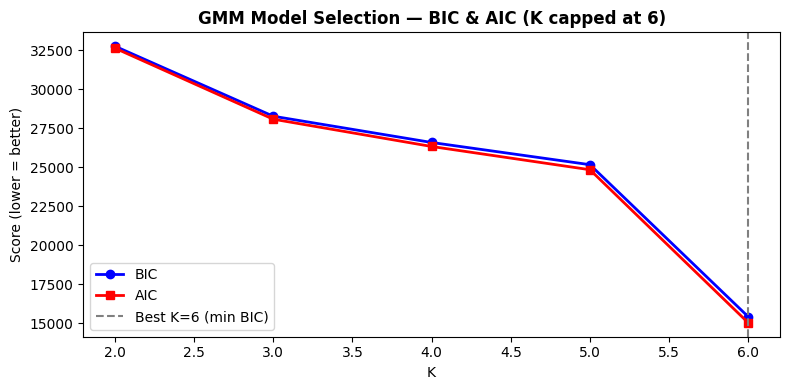

GMM optimal K (BIC): 6

K capped at 6: a marketing team cannot act on 7+ segments.
BIC can over-select K on large datasets — business interpretability sets the cap.

GMM certainty < 60%: 327 customers (6.1%),for 327 out of your total customers (which is 6.1%), the(GMM) was not very confident about their cluster assignment 
These sit genuinely between segments — K-Means forces them; GMM reflects ambiguity.


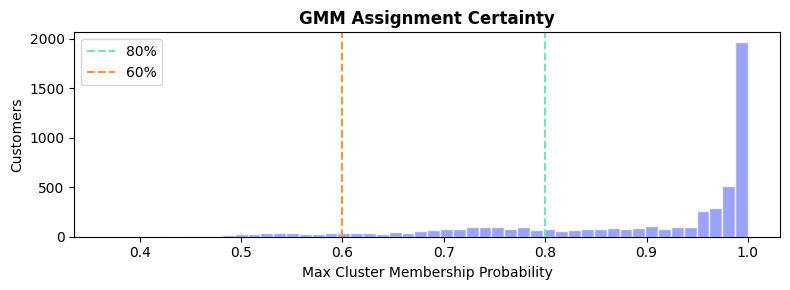

In [ ]:
# GMM: BIC selection (capped K≤6)
K_MAX_GMM = 6
bic_list, aic_list = [], []

for k in range(2, K_MAX_GMM+1):
    g = GaussianMixture(n_components=k, covariance_type='full',
                         n_init=5, random_state=42)
    g.fit(X_scaled)
    bic_list.append(g.bic(X_scaled))
    aic_list.append(g.aic(X_scaled))

best_k_gmm = int(np.argmin(bic_list)) + 2

fig, ax = plt.subplots(figsize=(8, 4))
k_range_gmm = list(range(2, K_MAX_GMM+1))
ax.plot(k_range_gmm, bic_list, 'bo-', linewidth=2, label='BIC')
ax.plot(k_range_gmm, aic_list, 'rs-', linewidth=2, label='AIC')
ax.axvline(best_k_gmm, color='gray', linestyle='--',
            label=f'Best K={best_k_gmm} (min BIC)')
ax.set_xlabel('K'); ax.set_ylabel('Score (lower = better)')
ax.set_title('GMM Model Selection — BIC & AIC (K capped at 6)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'GMM optimal K (BIC): {best_k_gmm}')
print()
print('K capped at 6: a marketing team cannot act on 7+ segments.')
print('BIC can over-select K on large datasets — business interpretability sets the cap.')

# Fit GMM
gmm_final = GaussianMixture(n_components=best_k_gmm, covariance_type='full',
                              n_init=10, random_state=42)
gmm_final.fit(X_scaled)
rfm['gmm_cluster']   = gmm_final.predict(X_scaled)
gmm_probs            = gmm_final.predict_proba(X_scaled)
rfm['gmm_certainty'] = gmm_probs.max(axis=1)

low_cert = (rfm['gmm_certainty'] < 0.6).sum()
print(f'\nGMM certainty < 60%: {low_cert:,} customers ({low_cert/len(rfm)*100:.1f}%),for {low_cert:,} out of your total customers (which is {low_cert/len(rfm)*100:.1f}%), the(GMM) was not very confident about their cluster assignment ')

print('These sit genuinely between segments — K-Means forces them; GMM reflects ambiguity.')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(rfm['gmm_certainty'], bins=50, color='#818cf8', edgecolor='white', alpha=0.8)
ax.axvline(0.8, color='#6ee7b7', linestyle='--', label='80%')
ax.axvline(0.6, color='#fb923c', linestyle='--', label='60%')
ax.set_xlabel('Max Cluster Membership Probability')
ax.set_ylabel('Customers')
ax.set_title('GMM Assignment Certainty', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

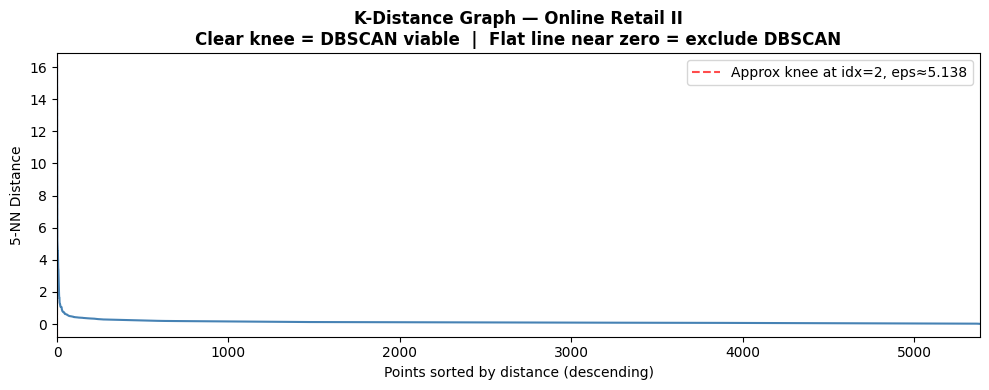

** K-Distance Distribution **
  Min:    0.0148
  P25:    0.1335
  Median: 0.0930
  P75:    0.0690
  Max:    16.0625
  IQR:    0.0645

Decision guide:
  If most distances cluster near zero with a long flat region--> no density structure--> exclude
  If clear step change / hockey stick shape --> density structure exists --> test DBSCAN

  99.8% of distances are within 20% of minimum distance
  Graph is flat-dominated. No meaningful density variation.
  DBSCAN is NOT appropriate for this dataset.

DBSCAN_VIABLE = False


In [ ]:
#DBSCAN Diagnostic: K-Distance Graph
# This determines whether DBSCAN is appropriate for this dataset.
# A clear 'knee'-- DBSCAN can find meaningful clusters.
# A flat line near zero-- no density structure → exclude with evidence.

from sklearn.neighbors import NearestNeighbors

K_NN = 5  # standard choice: same as min_samples for DBSCAN
nbrs = NearestNeighbors(n_neighbors=K_NN).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
kth_distances = np.sort(distances[:, K_NN - 1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(kth_distances, color='steelblue', linewidth=1.5)
ax.set_xlabel('Points sorted by distance (descending)')
ax.set_ylabel(f'{K_NN}-NN Distance')
ax.set_title(
    'K-Distance Graph — Online Retail II\n'
    'Clear knee = DBSCAN viable  |  Flat line near zero = exclude DBSCAN',
    fontweight='bold'
)
ax.set_xlim(0, len(kth_distances))

# Annotate the approximate knee using max curvature
# Simple approach: find index where second derivative is maximum
if len(kth_distances) > 10:
    smooth = np.convolve(kth_distances, np.ones(10)/10, mode='valid')
    d2     = np.diff(np.diff(smooth))
    knee_idx = int(np.argmax(d2)) + 1
    knee_val = float(kth_distances[knee_idx])
    ax.axvline(knee_idx, color='red', linestyle='--', alpha=0.7,
               label=f'Approx knee at idx={knee_idx}, eps≈{knee_val:.3f}')
    ax.legend()

plt.tight_layout()
plt.show()

# ── Statistical summary to support the decision
print('** K-Distance Distribution **')
print(f'  Min:    {kth_distances.min():.4f}')
print(f'  P25:    {np.percentile(kth_distances, 75):.4f}')  # 25% from top = P75 of sorted desc
print(f'  Median: {np.median(kth_distances):.4f}')
print(f'  P75:    {np.percentile(kth_distances, 25):.4f}')
print(f'  Max:    {kth_distances.max():.4f}')
print(f'  IQR:    {np.percentile(kth_distances,75) - np.percentile(kth_distances,25):.4f}')
print()
print('Decision guide:')
print('  If most distances cluster near zero with a long flat region--> no density structure--> exclude')
print('  If clear step change / hockey stick shape --> density structure exists --> test DBSCAN')
print()

# Flat-line test: if 80% of distances are within 20% of the minimum, it is flat
min_d  = kth_distances.min()
max_d  = kth_distances.max()
range_d = max_d - min_d
pct_near_min = (kth_distances < min_d + 0.20 * range_d).mean() * 100

print(f'  {pct_near_min:.1f}% of distances are within 20% of minimum distance')
if pct_near_min > 60:
    print('  Graph is flat-dominated. No meaningful density variation.')
    print('  DBSCAN is NOT appropriate for this dataset.')
    DBSCAN_VIABLE = False
else:
    print('  Graph shows variation. DBSCAN MAY be appropriate — run parameter grid.')
    DBSCAN_VIABLE = True

print(f'\nDBSCAN_VIABLE = {DBSCAN_VIABLE}')

In [ ]:
rfm.head()

,Customer ID,frequency,monetary,total_spend,recency,r_score,f_score,m_score,rfm_score,segment,km_cluster,km_label,gmm_cluster,gmm_certainty
0,12347,8,22.266087,5633.32,1,5,4,4,13,Champions,0,Mid-Low,2,0.618391
1,12349,4,25.306800,4428.69,18,5,3,5,13,Potential Loyalists,0,Mid-Low,0,0.581845
2,12350,1,19.670588,334.40,309,2,1,4,7,Hibernating,1,Low Value,1,0.996866
3,12351,1,14.330000,300.93,374,2,1,2,5,Hibernating,1,Low Value,1,0.996654
4,12352,10,27.668350,2849.84,35,4,5,5,14,Champions,2,Mid-High,2,0.630330


### Cluster Correspondence for 'Champions' Segment

In [ ]:
champions_df = rfm[rfm['segment'] == 'Champions']

print("K-Means clusters for Champions segment:")
display(champions_df['km_cluster'].value_counts())

print("\nGMM clusters for Champions segment:")
display(champions_df['gmm_cluster'].value_counts())

K-Means clusters for Champions segment:


,count
km_cluster,
0,624
2,204
3,4



GMM clusters for Champions segment:


,count
gmm_cluster,
2,501
0,252
5,42
3,37


## Section 4 — Probabilistic CLV: BG/NBD + Gamma-Gamma

### Statistical Context

**BG/NBD (Beta-Geometric / Negative Binomial Distribution)**

This model is used to predict a customer's *future transactions* and their *probability of being 'alive' (active)* in the future. It's particularly useful for non-contractual settings where you don't explicitly know when a customer has churned.

The model works by simultaneously estimating two latent (unobservable) processes for each customer:

1.  **Purchase Process**: While a customer is active, they make purchases at a certain rate (λ). This rate is assumed to follow a Gamma distribution, meaning some customers buy more frequently than others.
2.  **Dropout Process**: After each purchase, a customer has a certain probability (p) of 'churning' (becoming inactive). This probability is assumed to follow a Beta distribution, meaning some customers are more likely to churn than others.

The model takes observed data (customer frequency, recency, and time elapsed since their first purchase 'T') and uses maximum likelihood estimation to figure out the best values for four parameters: {r, α, a, b}. These parameters describe the overall shape of the Gamma and Beta distributions across your entire customer base.

**Gamma-Gamma model**

Once we have a way to predict *how many* future transactions a customer will make (from BG/NBD), we also need to know *how much* they will spend per transaction. That's where the Gamma-Gamma model comes in.

This model is used to predict a customer's *expected average monetary value per transaction* (i.e., how much they will spend on average each time they buy).

It assumes that the monetary value of a customer's transactions is independently distributed and follows a Gamma distribution. Crucially, it assumes that the monetary value *does not* depend on the purchase frequency, allowing it to be modeled separately from the BG/NBD process.

**Important Requirement**: This model can only be applied to customers who have made at least one repeat purchase (frequency > 0), as it needs transaction history to estimate average spend.

**Combined CLV:**

By combining these two models, we can get a comprehensive Customer Lifetime Value (CLV) estimate:

$$CLV = E[\text{transactions}] \times E[\text{spend per transaction}] \times \text{margin}$$

Where:
*   $E[\text{transactions}]$ comes from the BG/NBD model (expected future purchases).
*   $E[\text{spend per transaction}]$ comes from the Gamma-Gamma model (expected average monetary value).
*   $\text{margin}$ is your business's average profit margin on sales.



In [ ]:
# Prepare BG/NBD input
bgf_data = summary_data_from_transaction_data(
    df_retail.rename(columns={                           # to match the lifetime library
        'Customer ID': 'customer_id',
        'InvoiceDate': 'date',
        'order_value': 'monetary_value'
    }),
    customer_id_col   ='customer_id',
    datetime_col      ='date',
    monetary_value_col='monetary_value',
    observation_period_end=snapshot
)  # to match the lifetime library

print('** BG/NBD Input Format **')
print('frequency = repeat purchases (total_orders - 1)')
print('recency   = days from first to last purchase')
print('T         = days since first purchase to observation date')
print()
print(bgf_data.describe().round(2))
print(f'\nOne-time buyers (frequency=0): {(bgf_data["frequency"]==0).sum():,} ({(bgf_data["frequency"]==0).mean()*100:.1f}%)')
print(f'Repeat buyers  (frequency>=1): {(bgf_data["frequency"]>=1).sum():,} ({(bgf_data["frequency"]>=1).mean()*100:.1f}%)')

** BG/NBD Input Format **
frequency = repeat purchases (total_orders - 1)
recency   = days from first to last purchase
T         = days since first purchase to observation date

       frequency  recency        T  monetary_value
count    5384.00  5384.00  5384.00         5384.00
mean        4.45   274.25   472.40          256.56
std         9.55   257.59   223.53          309.47
min         0.00     0.00     0.00            0.00
25%         0.00     0.00   310.00            0.00
50%         2.00   224.00   528.50          212.50
75%         5.00   511.00   666.00          363.77
max       254.00   738.00   738.00         8322.12

One-time buyers (frequency=0): 1,513 (28.1%)
Repeat buyers  (frequency>=1): 3,871 (71.9%)


In [ ]:
# Fit BG/NBD
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(bgf_data['frequency'], bgf_data['recency'], bgf_data['T'])

print('** BG/NBD Model Parameters **')
print(bgf.summary)


** BG/NBD Model Parameters **
            coef  se(coef)  lower 95% bound  upper 95% bound
r       0.688654  0.016913         0.655505         0.721803
alpha  67.252424  2.129166        63.079258        71.425589
a       0.045142  0.004673         0.035983         0.054302
b       0.594199  0.057410         0.481676         0.706722


**BG/NBD Model Interpretation**


**Model Parameters**

- **r = 0.69**  
  Indicates moderate heterogeneity in purchase frequency across customers. Customers show different buying rates, but the variation is not extreme.

- **alpha = 67.25**  
  Suggests a moderate overall purchase rate, meaning customers tend to have relatively long intervals between purchases.

- **a = 0.045**  
  Reflects strong variation in customer churn behavior. Some customers are highly loyal, while others are more likely to become inactive quickly.

- **b = 0.59**  
  A shape parameter of the dropout distribution.

---

**Expected Dropout Probability**

The average probability that a customer becomes inactive after a purchase is given by:


This implies that, on average, customers have approximately a **7% chance of dropping out after a purchase**.  a / a+b

---

**Model Reliability**

The relatively small standard errors and narrow confidence intervals indicate that the parameter estimates are stable and reliable.

---
**Business Interpretation**

Overall, the results suggest a heterogeneous customer base with varying levels of loyalty and engagement.  
This makes the model suitable for:

In [ ]:
# Predict expected purchases: 90d and probability alive
bgf_data['predicted_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90, bgf_data['frequency'], bgf_data['recency'], bgf_data['T']  # predicted_purchases_90d = number of purchase
)
bgf_data['prob_alive'] = bgf.conditional_probability_alive(
    bgf_data['frequency'], bgf_data['recency'], bgf_data['T']
)

print('** Predicted Purchases, Next 90 Days **')
print(bgf_data['predicted_purchases_90d'].describe().round(4))
print()
print('Top 10 customers by predicted future purchases:')
print(bgf_data.nlargest(10,'predicted_purchases_90d')
      [['frequency','recency','T','predicted_purchases_90d','prob_alive']].round(3))

** Predicted Purchases, Next 90 Days **
count    5035.0000
mean        0.7981
std         1.2028
min         0.0000
25%         0.1668
50%         0.4413
75%         1.0283
max        28.3892
Name: predicted_purchases_90d, dtype: float64

Top 10 customers by predicted future purchases:
             frequency  recency      T  predicted_purchases_90d  prob_alive
customer_id                                                                
14911            254.0    737.0  738.0                   28.389       1.000
12748            201.0    735.0  735.0                   22.566       1.000
15311            195.0    738.0  738.0                   21.813       1.000
17841            192.0    736.0  737.0                   21.504       1.000
14606            180.0    735.0  736.0                   20.189       1.000
13089            131.0    735.0  737.0                   14.693       1.000
14527            120.0    735.0  737.0                   13.466       0.999
12971             98.0    721

In [ ]:
# Gamma-Gamma model
gg_data = bgf_data[(bgf_data['frequency'] > 0) & (bgf_data['monetary_value'] > 0)].copy()
print(f'Customers eligible for Gamma-Gamma: {len(gg_data):,} ({len(gg_data)/len(bgf_data)*100:.1f}%)')
print('One-time buyers excluded, Gamma-Gamma needs repeat purchase history.')

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(gg_data['frequency'], gg_data['monetary_value'])

print('\n** Gamma-Gamma Parameters **')
print(ggf.summary)

Customers eligible for Gamma-Gamma: 3,871 (71.9%)
One-time buyers excluded, Gamma-Gamma needs repeat purchase history.

** Gamma-Gamma Parameters **
       coef  se(coef)  lower 95% bound  upper 95% bound
p  3.808030  0.082748         3.645843         3.970217
q  0.343754  0.006262         0.331479         0.356028
v  3.709794  0.083506         3.546122         3.873467


** CLV Estimates **

90d:
  Median: £202.68
  Mean:   £401.26
  Total:  £1,553,270

12m:
  Median: £765.41
  Mean:   £1518.33
  Total:  £5,877,461


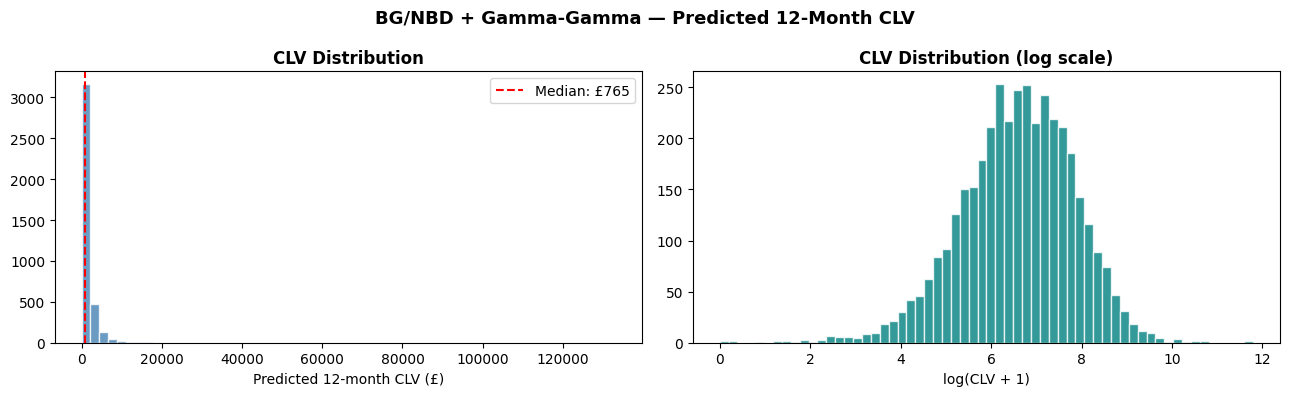

In [ ]:
# Full CLV: 90-day and 12-month
for months, label in [(3,'90d'), (12,'12m')]:
    clv = ggf.customer_lifetime_value(
        bgf,
        gg_data['frequency'], gg_data['recency'],
        gg_data['T'], gg_data['monetary_value'],
        time=months, discount_rate=0.01
    )
    gg_data[f'clv_{label}']        = clv.values
    gg_data[f'clv_{label}_profit'] = clv.values * PROFIT_MARGIN

print('** CLV Estimates **')
for label in ['90d','12m']:
    col = f'clv_{label}'
    print(f'\n{label}:')
    print(f'  Median: £{gg_data[col].median():.2f}')
    print(f'  Mean:   £{gg_data[col].mean():.2f}')
    print(f'  Total:  £{gg_data[col].sum():,.0f}')

# Merge back
clv_merge = gg_data[['clv_90d','clv_12m','clv_12m_profit','prob_alive']].copy()
clv_merge.index.name = 'Customer ID'
clv_merge = clv_merge.reset_index()
rfm = rfm.merge(clv_merge, on='Customer ID', how='left')

# CLV distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
clv_vals = gg_data['clv_12m']
axes[0].hist(clv_vals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(clv_vals.median(), color='red', linestyle='--',
                 label=f'Median: £{clv_vals.median():.0f}')
axes[0].set_xlabel('Predicted 12-month CLV (£)')
axes[0].set_title('CLV Distribution', fontweight='bold')
axes[0].legend()
axes[1].hist(np.log1p(clv_vals), bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log(CLV + 1)')
axes[1].set_title('CLV Distribution (log scale)', fontweight='bold')
plt.suptitle('BG/NBD + Gamma-Gamma — Predicted 12-Month CLV',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
gg_data.head(5)

,frequency,recency,T,monetary_value,predicted_purchases_90d,prob_alive,clv_90d,clv_90d_profit,clv_12m,clv_12m_profit
customer_id,,,,,,,,,,
12347,7.0,402.0,404.0,717.398571,1.451403,0.992976,1047.309150,157.096372,3965.221954,594.783293
12349,3.0,571.0,589.0,1120.056667,0.494429,0.981083,576.626883,86.494033,2186.523516,327.978527
12352,8.0,356.0,392.0,338.261250,1.674619,0.988062,568.330691,85.249604,2151.565322,322.734798
12353,1.0,204.0,408.0,89.000000,0.265692,0.836224,29.176361,4.376454,110.054663,16.508199
12355,1.0,353.0,567.0,459.400000,0.206937,0.867881,113.513562,17.027034,429.373837,64.406075


** Probabilistic CLV by Segment **
            segment   n  avg_clv_12m  total_clv_12m  avg_prob_alive
          Champions 832      3298.25     2744142.57            0.99
    Loyal Customers 982      1879.35     1845526.20            0.98
      New Customers 193      1031.79      199135.60            0.91
Potential Loyalists 644       982.46      632707.23            0.94
   Cannot Lose Them 134       679.72       91082.87            0.66
     Need Attention 126       522.92       65887.68            0.86
            At Risk 618       370.76      229132.36            0.67
        Hibernating 342       204.23       69846.51            0.62


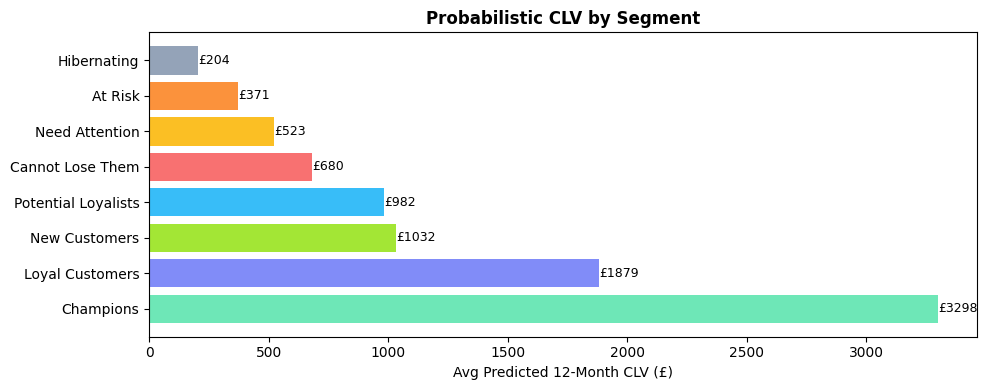

In [ ]:
# CLV by segment
clv_by_seg = (
    rfm.dropna(subset=['clv_12m'])
    .groupby('segment')
    .agg(n=('Customer ID','count'),
         avg_clv_12m=('clv_12m','mean'),
         total_clv_12m=('clv_12m','sum'),
         avg_prob_alive=('prob_alive','mean'))
    .reset_index()
    .sort_values('avg_clv_12m', ascending=False)
)
print('** Probabilistic CLV by Segment **')
print(clv_by_seg.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors = [SEGMENT_COLORS.get(s,'#64748b') for s in clv_by_seg['segment']]
ax.barh(clv_by_seg['segment'], clv_by_seg['avg_clv_12m'], color=colors)
for i, v in enumerate(clv_by_seg['avg_clv_12m']):
    ax.text(v+1, i, f'£{v:.0f}', va='center', fontsize=9)
ax.set_xlabel('Avg Predicted 12-Month CLV (£)')
ax.set_title('Probabilistic CLV by Segment', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 5: ML CLV: Time-Based Prediction

### Design Decisions

**Time-based split — the correct predictive architecture:**
- Features: behaviour from transactions **before T0** (past)
- Target:   actual spend from transactions **after T0** (future)
- No feature shares data with the target → genuine out-of-sample prediction
- Improvement over the tutorial: final evaluation on held-out test set, not training data

**Two models:**
- **Regression**: how much will they spend? (continuous £ target)
- **Classification**: will they purchase at all? (binary target)
- **Combined**: E[value] = P(purchase) × predicted_spend

**Why Tweedie loss for regression:**
Spend is zero-inflated (many customers spend £0 in any quarter) and right-skewed.
Standard MSE assumes normal errors, violated here.
Tweedie distribution is designed for this pattern.

**Feature engineering improvements over tutorial:**
- Rolling 28-day and 14-day windows (tutorial has these)
- Product diversity features: n_unique_products, n_unique_descriptions (tutorial hints at but skips)

In [ ]:
# Time split
PREDICTION_HORIZON_DAYS  = 90

T0     = snapshot - pd.Timedelta(days=PREDICTION_HORIZON_DAYS)
df_in  = df_retail[df_retail['InvoiceDate'] <= T0].copy()
df_out = df_retail[df_retail['InvoiceDate'] >  T0].copy()

print(f'Dataset ends:    {snapshot.date()}')
print(f'Split point T0:  {T0.date()}')
print(f'Horizon:         {PREDICTION_HORIZON_DAYS} days')
print(f'df_in  (features):  {len(df_in):,} transactions, {df_in["Customer ID"].nunique():,} customers')
print(f'df_out (targets):   {len(df_out):,} transactions, {df_out["Customer ID"].nunique():,} customers')
print()
print('Window choice justification:')
print('  90 days = one business quarter.')
print('  Long enough for meaningful spend; short enough to be actionable.')

Dataset ends:    2011-12-09
Split point T0:  2011-09-10
Horizon:         90 days
df_in  (features):  611,054 transactions, 4,828 customers
df_out (targets):   155,320 transactions, 2,683 customers

Window choice justification:
  90 days = one business quarter.
  Long enough for meaningful spend; short enough to be actionable.


In [ ]:
# Targets from df_out
targets = (
    df_out.groupby('Customer ID')
    .agg(sales_90_value=('order_value','sum'))
    .reset_index()
)
targets['purchased_flag'] = 1

# Feature engineering from df_in only (NO data from df_out)
# 1. Base RFM features
feat_base = (
    df_in.groupby('Customer ID')
    .agg(
        last_purchase    =('InvoiceDate',  'max'),
        frequency        =('Invoice',      'nunique'),
        sales_value_sum  =('order_value',  'sum'),
        sales_value_avg  =('order_value',  'mean'),
        quantity_avg     =('Quantity',     'mean'),
    )
    .reset_index()
)
feat_base['recency'] = (T0 - feat_base['last_purchase']).dt.days
feat_base = feat_base.drop(columns=['last_purchase'])

# 2. Rolling 28-day
df_28  = df_in[df_in['InvoiceDate'] >= T0 - pd.Timedelta(days=28)]
feat_28 = (
    df_28.groupby('Customer ID')
    .agg(txn_last_28d=('Invoice','nunique'),
         spend_last_28d=('order_value','sum'))
    .reset_index()
)

# 3. Rolling 14-day
df_14  = df_in[df_in['InvoiceDate'] >= T0 - pd.Timedelta(days=14)]
feat_14 = (
    df_14.groupby('Customer ID')
    .agg(txn_last_14d=('Invoice','nunique'),
         spend_last_14d=('order_value','sum'))
    .reset_index()
)

# 4. Product diversity (added here)
feat_div = (
    df_in.groupby('Customer ID')
    .agg(n_unique_products=('StockCode','nunique'),
         n_unique_desc    =('Description','nunique'))
    .reset_index()
)

# Combine
features = (
    feat_base
    .merge(feat_28, on='Customer ID', how='left')
    .merge(feat_14, on='Customer ID', how='left')
    .merge(feat_div,on='Customer ID', how='left')
    .fillna(0)
)

feature_cols = [c for c in features.columns if c != 'Customer ID']
print(f'Feature matrix: {features.shape}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

Feature matrix: (4828, 12)
Features (11): ['frequency', 'sales_value_sum', 'sales_value_avg', 'quantity_avg', 'recency', 'txn_last_28d', 'spend_last_28d', 'txn_last_14d', 'spend_last_14d', 'n_unique_products', 'n_unique_desc']


In [ ]:
features

,Customer ID,frequency,sales_value_sum,sales_value_avg,quantity_avg,recency,txn_last_28d,spend_last_28d,txn_last_14d,spend_last_14d,n_unique_products,n_unique_desc
0,12347,6,4114.18,21.098359,12.400000,39,0.0,0.0,0.0,0.0,107,107
1,12349,3,2671.14,26.187647,9.735294,317,0.0,0.0,0.0,0.0,90,94
2,12350,1,334.40,19.670588,11.588235,219,0.0,0.0,0.0,0.0,17,17
3,12351,1,300.93,14.330000,12.428571,284,0.0,0.0,0.0,0.0,21,21
4,12352,7,1905.61,34.028750,7.892857,171,0.0,0.0,0.0,0.0,38,38
...,...,...,...,...,...,...,...,...,...,...,...,...
4823,18283,16,1762.44,2.603309,1.592319,5,1.0,134.9,1.0,134.9,285,302
4824,18284,1,461.68,16.488571,17.642857,341,0.0,0.0,0.0,0.0,28,28
4825,18285,1,427.00,35.583333,12.083333,570,0.0,0.0,0.0,0.0,12,12
4826,18286,2,1296.43,19.349701,9.074627,386,0.0,0.0,0.0,0.0,67,67


In [ ]:
# Model dataset
model_df = features.merge(targets, on='Customer ID', how='left')
model_df['sales_90_value'] = model_df['sales_90_value'].fillna(0)
model_df['purchased_flag'] = model_df['purchased_flag'].fillna(0).astype(int)

print(f'Model dataset: {len(model_df):,} customers')
print(f'Purchased in 90d window: {model_df["purchased_flag"].sum():,} ({model_df["purchased_flag"].mean()*100:.1f}%)')
print()
print('Target statistics (sales_90_value):')
print(model_df['sales_90_value'].describe().round(2))
print(f'Skewness: {model_df["sales_90_value"].skew():.3f}')
print(f'Zeros:    {(model_df["sales_90_value"]==0).sum():,} ({(model_df["sales_90_value"]==0).mean()*100:.1f}%)')
print()
print('Zero-inflated, right-skewed target -> Tweedie loss is the appropriate choice.')

Model dataset: 4,828 customers
Purchased in 90d window: 2,127 (44.1%)

Target statistics (sales_90_value):
count     4828.00
mean       399.18
std       1573.59
min          0.00
25%          0.00
50%          0.00
75%        430.74
max      64920.11
Name: sales_90_value, dtype: float64
Skewness: 28.249
Zeros:    2,701 (55.9%)

Zero-inflated, right-skewed target -> Tweedie loss is the appropriate choice.


In [ ]:
model_df

,Customer ID,frequency,sales_value_sum,sales_value_avg,quantity_avg,recency,txn_last_28d,spend_last_28d,txn_last_14d,spend_last_14d,n_unique_products,n_unique_desc,sales_90_value,purchased_flag
0,12347,6,4114.18,21.098359,12.400000,39,0.0,0.0,0.0,0.0,107,107,1519.14,1
1,12349,3,2671.14,26.187647,9.735294,317,0.0,0.0,0.0,0.0,90,94,1757.55,1
2,12350,1,334.40,19.670588,11.588235,219,0.0,0.0,0.0,0.0,17,17,0.00,0
3,12351,1,300.93,14.330000,12.428571,284,0.0,0.0,0.0,0.0,21,21,0.00,0
4,12352,7,1905.61,34.028750,7.892857,171,0.0,0.0,0.0,0.0,38,38,944.23,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4823,18283,16,1762.44,2.603309,1.592319,5,1.0,134.9,1.0,134.9,285,302,974.21,1
4824,18284,1,461.68,16.488571,17.642857,341,0.0,0.0,0.0,0.0,28,28,0.00,0
4825,18285,1,427.00,35.583333,12.083333,570,0.0,0.0,0.0,0.0,12,12,0.00,0
4826,18286,2,1296.43,19.349701,9.074627,386,0.0,0.0,0.0,0.0,67,67,0.00,0


### 5.1 - Regression: How Much Will They Spend?

In [ ]:
X   = model_df[feature_cols].values
y_r = model_df['sales_90_value'].values  #regression
y_c = model_df['purchased_flag'].values  #classification

X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_r, y_c, test_size=0.2, random_state=42
)

# XGBoost Regression, Tweedie loss
xgb_reg = XGBRegressor(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:tweedie', tweedie_variance_power=1.5,  #many customers spend £0 in a given period(tweedie)
    random_state=42, n_jobs=-1
)

cv_kf  = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(xgb_reg, X_train, yr_train, cv=cv_kf, scoring='r2')
cv_mae = -cross_val_score(xgb_reg, X_train, yr_train, cv=cv_kf,
                           scoring='neg_mean_absolute_error')

print('** XGBoost Regression (Tweedie), 5-Fold CV **')
print(f'  R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  MAE : £{cv_mae.mean():.2f} ± £{cv_mae.std():.2f}')
print()
print('R² reference:')
print('  1.00 → perfect (suspect, leakage)')
print('  0.60-0.80 → good for CLV regression')
print('  0.30-0.60 → acceptable given zero-inflation')
print('  < 0.10 → no predictive power')

xgb_reg.fit(X_train, yr_train)
yr_pred = np.maximum(xgb_reg.predict(X_test), 0)

print(f'\n** Test Set Performance **')
print(f'  R²   : {r2_score(yr_test, yr_pred):.4f}')
print(f'  MAE  : £{mean_absolute_error(yr_test, yr_pred):.2f}')
print(f'  RMSE : £{np.sqrt(mean_squared_error(yr_test, yr_pred)):.2f}')
print(f'  MAE = on average, prediction is off by £{mean_absolute_error(yr_test, yr_pred):.2f} per customer')

** XGBoost Regression (Tweedie), 5-Fold CV **
  R²  : 0.2837 ± 0.1224
  MAE : £326.67 ± £37.59

R² reference:
  1.00 → perfect (suspect, leakage)
  0.60-0.80 → good for CLV regression
  0.30-0.60 → acceptable given zero-inflation
  < 0.10 → no predictive power

** Test Set Performance **
  R²   : 0.6297
  MAE  : £302.45
  RMSE : £674.64
  MAE = on average, prediction is off by £302.45 per customer


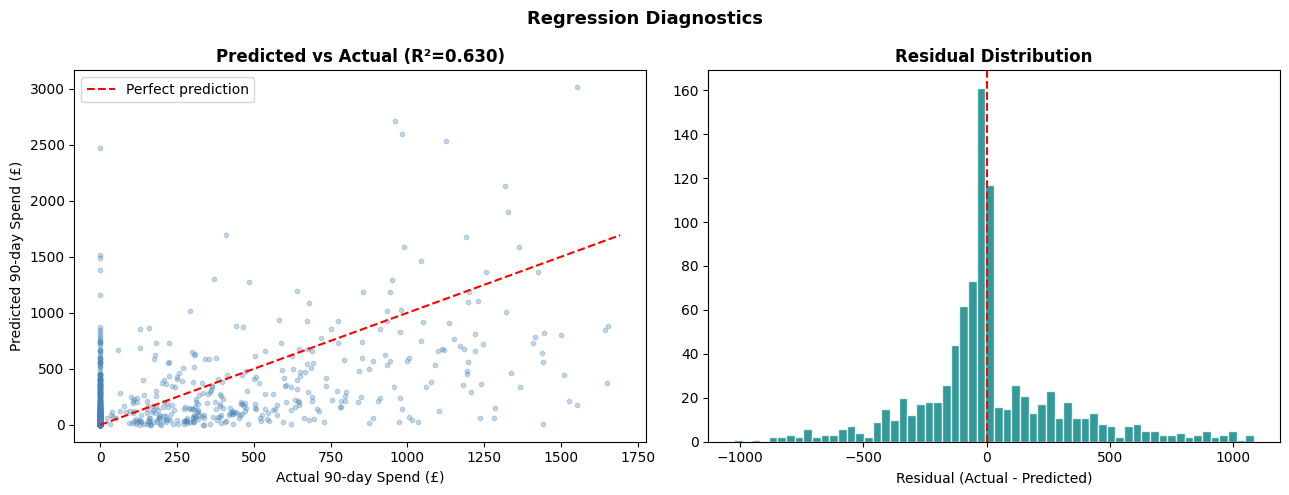


Predicted vs. Actual: Ideally, points should fall close to the red dashed line 

Residual Distribution: Ideally, these errors should be centered around zero and be somewhat normally distributed.


In [ ]:
# Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cap  = np.percentile(yr_test, 95)
mask = yr_test <= cap
axes[0].scatter(yr_test[mask], yr_pred[mask], alpha=0.3, s=10, color='steelblue')
axes[0].plot([0,cap],[0,cap],'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual 90-day Spend (£)')
axes[0].set_ylabel('Predicted 90-day Spend (£)')
axes[0].set_title(f'Predicted vs Actual (R²={r2_score(yr_test,yr_pred):.3f})',
                   fontweight='bold')
axes[0].legend()

residuals = yr_test - yr_pred
cap_r     = np.percentile(np.abs(residuals), 95)
axes[1].hist(residuals[np.abs(residuals) <= cap_r], bins=60,
             color='teal', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Regression Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPredicted vs. Actual: Ideally, points should fall close to the red dashed line ')
print('\nResidual Distribution: Ideally, these errors should be centered around zero and be somewhat normally distributed.')

### 5.2 - Classification: Will They Purchase?

In [ ]:
# XGBoost Classification
neg, pos = (yc_train==0).sum(), (yc_train==1).sum()
spw      = neg / pos  # handles class imbalance

xgb_clf = XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc   = cross_val_score(xgb_clf, X_train, yc_train, cv=cv_strat, scoring='roc_auc')
cv_f1    = cross_val_score(xgb_clf, X_train, yc_train, cv=cv_strat, scoring='f1')

print('** XGBoost Classification — 5-Fold Stratified CV **')
print(f'  AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'  F1:  {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')

xgb_clf.fit(X_train, yc_train)
yc_prob = xgb_clf.predict_proba(X_test)[:,1]

# Optimal threshold from ROC
fpr, tpr, thresholds = roc_curve(yc_test, yc_prob)
opt_idx   = (tpr - fpr).argmax()
opt_thresh = round(float(thresholds[opt_idx]), 3)

yc_pred_def = (yc_prob >= 0.50).astype(int)
yc_pred_opt = (yc_prob >= opt_thresh).astype(int)

print(f'\n** Threshold Analysis **')
print(f'  Default  (0.50): F1={f1_score(yc_test,yc_pred_def):.4f}')
print(f'  Optimal  ({opt_thresh}): F1={f1_score(yc_test,yc_pred_opt):.4f}')
print(f'  AUC: {roc_auc_score(yc_test,yc_prob):.4f}')
print(f'\nUsing optimal threshold: {opt_thresh}')
print(classification_report(yc_test, yc_pred_opt))

** XGBoost Classification — 5-Fold Stratified CV **
  AUC: 0.7774 ± 0.0106
  F1:  0.6703  ± 0.0154

** Threshold Analysis **
  Default  (0.50): F1=0.6494
  Optimal  (0.462): F1=0.6712
  AUC: 0.7576

Using optimal threshold: 0.462
              precision    recall  f1-score   support

           0       0.76      0.70      0.73       548
           1       0.64      0.71      0.67       418

    accuracy                           0.70       966
   macro avg       0.70      0.70      0.70       966
weighted avg       0.71      0.70      0.70       966



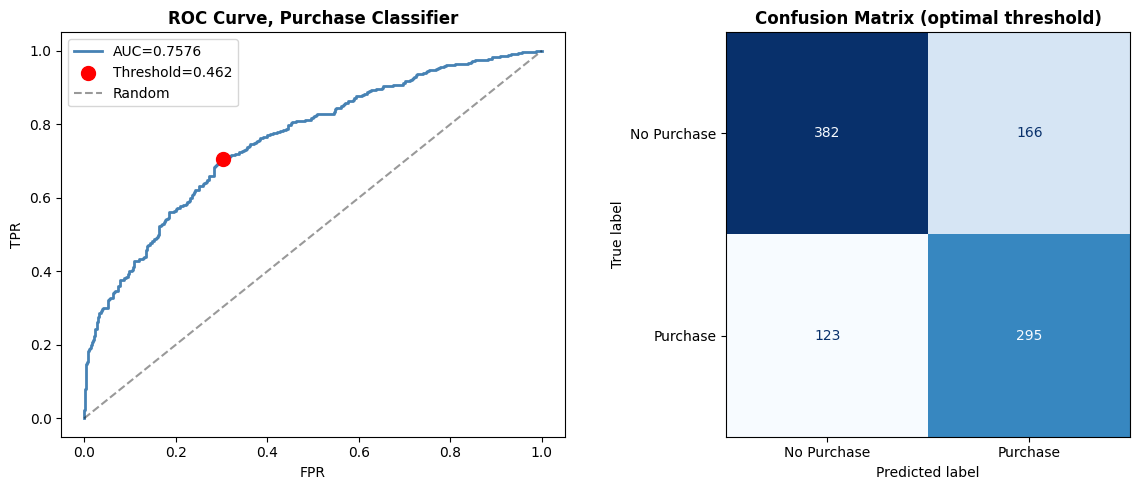

In [ ]:
# ROC + Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUC={roc_auc_score(yc_test,yc_prob):.4f}')
axes[0].scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=100, zorder=5,
                 label=f'Threshold={opt_thresh}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve, Purchase Classifier', fontweight='bold')
axes[0].legend()

cm = confusion_matrix(yc_test, yc_pred_opt)
ConfusionMatrixDisplay(cm, display_labels=['No Purchase','Purchase']).plot(
    ax=axes[1], cmap='Blues', colorbar=False
)
axes[1].set_title('Confusion Matrix (optimal threshold)', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 - Feature Importance (SHAP / Native XGBoost)

Regression SHAP — What drives 90-day spend?


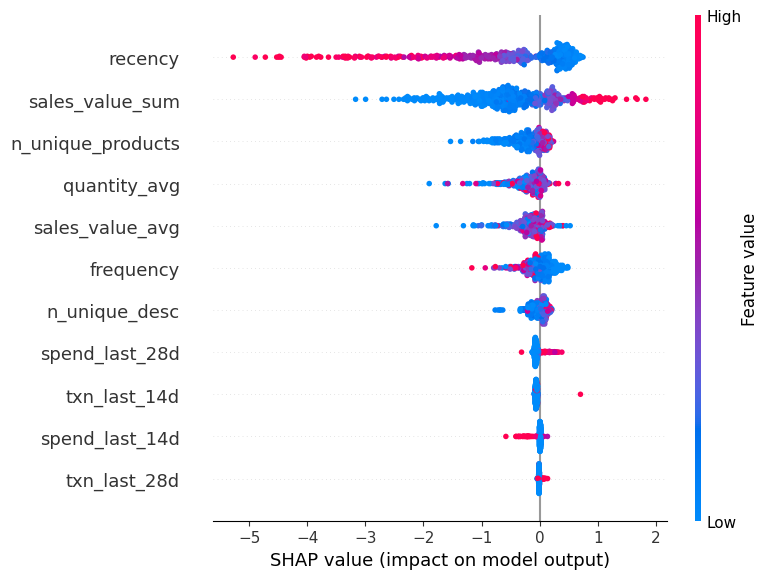

Classification SHAP — What drives P(purchase)?


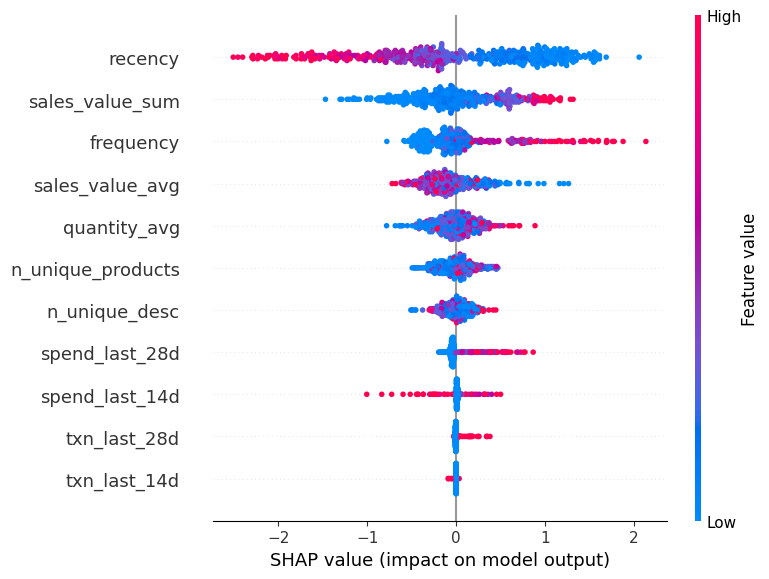


Expected pattern (from tutorial + validated here):
  Regression model:     sales_value_sum dominates — past high spenders spend more
  Classification model: txn_last_28d dominates  — recent activity predicts return

  These two models capture different signals and need each other.
  Using only one misses half the picture.



In [ ]:
SHAP_AVAILABLE = True # Define SHAP_AVAILABLE

if SHAP_AVAILABLE:
    import shap
    explainer_reg = shap.TreeExplainer(xgb_reg)
    shap_reg      = explainer_reg.shap_values(X_test[:500])
    print('Regression SHAP — What drives 90-day spend?')
    shap.summary_plot(shap_reg, X_test[:500], feature_names=feature_cols, show=True)

    explainer_clf = shap.TreeExplainer(xgb_clf)
    shap_clf      = explainer_clf.shap_values(X_test[:500])
    print('Classification SHAP — What drives P(purchase)?')
    shap.summary_plot(shap_clf, X_test[:500], feature_names=feature_cols, show=True)
else:
    fi_reg = pd.Series(xgb_reg.feature_importances_,
                        index=feature_cols).sort_values(ascending=True)
    fi_clf = pd.Series(xgb_clf.feature_importances_,
                        index=feature_cols).sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fi_reg.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Regression — Feature Importance\n(What drives spend amount?)',
                       fontweight='bold')
    fi_clf.plot(kind='barh', ax=axes[1], color='teal')
    axes[1].set_title('Classification — Feature Importance\n(What drives P(purchase)?)',
                       fontweight='bold')
    plt.tight_layout()
    plt.show()

print('''
Expected pattern (from tutorial + validated here):
  Regression model:     sales_value_sum dominates — past high spenders spend more
  Classification model: txn_last_28d dominates  — recent activity predicts return

  These two models capture different signals and need each other.
  Using only one misses half the picture.
''')

### 5.4 - Combined CLV Score: P(purchase) × Predicted Spend

In [ ]:
# Score all customers
X_all = model_df[feature_cols].values
model_df['pred_spend']   = np.maximum(xgb_reg.predict(X_all), 0)  #np.maximum(..., 0) is applied to ensure that no negative
                                                                  # spend predictions are generated
model_df['pred_prob']    = xgb_clf.predict_proba(X_all)[:,1]
model_df['pred_clv_90d'] = model_df['pred_spend'] * model_df['pred_prob']

print('** Combined CLV Score **')
print('Formula: E[value] = P(purchase) × E[spend | purchase]')
print(model_df['pred_clv_90d'].describe().round(2))

top20 = (
    model_df.nlargest(20, 'pred_clv_90d')
    [['Customer ID','pred_spend','pred_prob','pred_clv_90d','sales_90_value']]
    .round(2)
)
print('\nTop 20 customers by predicted 90-day CLV:')
print(top20.to_string(index=False))

** Combined CLV Score **
Formula: E[value] = P(purchase) × E[spend | purchase]
count     4828.00
mean       286.08
std       1326.76
min          0.00
25%          4.79
50%         53.41
75%        268.40
max      58423.92
Name: pred_clv_90d, dtype: float64

Top 20 customers by predicted 90-day CLV:
Customer ID   pred_spend  pred_prob  pred_clv_90d  sales_90_value
      14096 63361.101562       0.92  58423.921875        64920.11
      14911 55309.718750       1.00  55158.710938        61847.38
      12748 17455.369141       0.99  17333.529297        19611.98
      15311 15276.620117       1.00  15234.709961        14612.42
      13089  9874.370117       0.99   9802.120117        15501.34
      13098  9269.950195       0.98   9106.549805        13712.98
      17841  8912.849609       1.00   8873.769531        17489.71
      14298  8188.500000       0.98   7991.209961        10344.79
      13081  7328.040039       0.96   7060.720215         9467.26
      13767  6903.359863       0.99   6

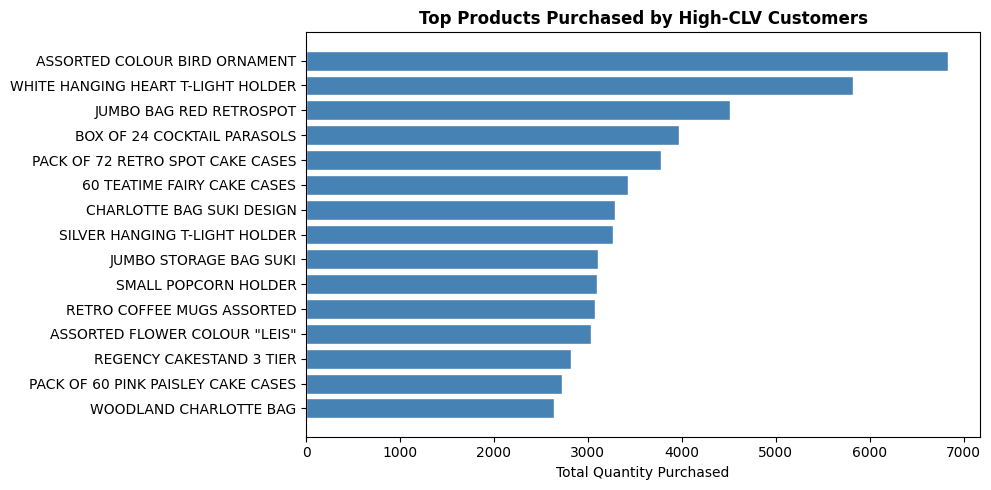


Business application:
  To increase purchase frequency --> target high-CLV customers with these products.
  These are the items that brought them back before.
  Personalised promotions on these SKUs(Stock Keeping Units.  products that your high-CLV customers are already buying frequently) = highest expected ROI(Return on Investment).



In [ ]:
# What are top customers buying?
top_ids = set(top20['Customer ID'])
top_products = (
    df_in[df_in['Customer ID'].isin(top_ids)]
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_products['Description'][::-1],
        top_products['Quantity'][::-1],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Total Quantity Purchased')
ax.set_title('Top Products Purchased by High-CLV Customers',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('''
Business application:
  To increase purchase frequency --> target high-CLV customers with these products.
  These are the items that brought them back before.
  Personalised promotions on these SKUs(Stock Keeping Units.  products that your high-CLV customers are already buying frequently) = highest expected ROI(Return on Investment).
''')

## Section 6 - Business Recommendations

### 6.1 - Segment-Level CLV Estimates

** Segment CLV Intelligence **
            segment  n_customers  avg_prob_alive  avg_clv_bgnbd  avg_clv_bgnbd_90d  avg_clv_ml_90d  total_revenue  revenue_%
          Champions          832            0.99        3298.25             869.60      927.780029     5572333.43       46.9
    Loyal Customers          982            0.98        1879.35             496.05      494.720001     3500789.52       29.5
      New Customers          412            0.91        1031.79             277.24       90.959999      202433.11        1.7
Potential Loyalists          650            0.94         982.46             261.90      140.639999      695077.59        5.8
   Cannot Lose Them          134            0.66         679.72             179.04       73.129997      441751.08        3.7
     Need Attention          354            0.86         522.92             139.27       61.279999      180524.49        1.5
            At Risk          632            0.67         370.76              97.81       43.02

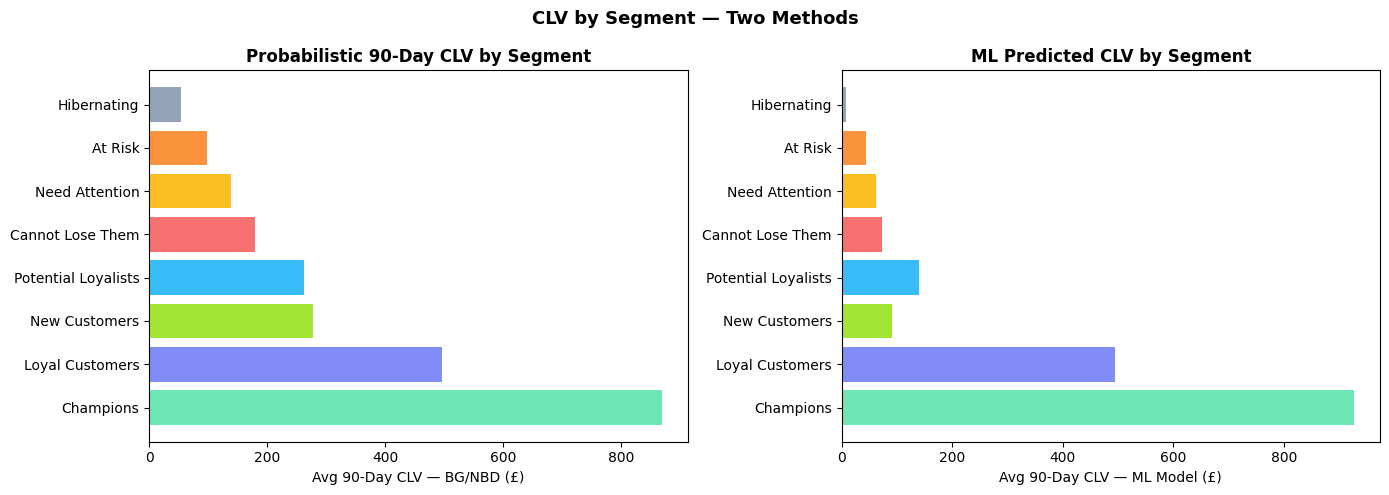


when BG/NBD and ML CLV rankings agree--> both methods capture the same signal.
   



In [ ]:
ml_scores = model_df[['Customer ID','pred_spend','pred_prob','pred_clv_90d']]
rfm_final = rfm.merge(ml_scores, on='Customer ID', how='left')

# Segment summary: BG/NBD + ML side by side
seg_clv = (
    rfm_final.groupby('segment')
    .agg(
        n_customers    =('Customer ID',  'count'),
        avg_prob_alive =('prob_alive',   'mean'),
        avg_clv_bgnbd  =('clv_12m',      'mean'),
        avg_clv_bgnbd_90d =('clv_90d',     'mean'), # Added 90-day probabilistic CLV
        avg_clv_ml_90d =('pred_clv_90d', 'mean'),
        total_revenue  =('total_spend',  'sum')
    )
    .reset_index()
    .sort_values('avg_clv_bgnbd', ascending=False, na_position='last')
)
seg_clv['revenue_%'] = (seg_clv['total_revenue']/seg_clv['total_revenue'].sum()*100).round(1)
print('** Segment CLV Intelligence **')
print(seg_clv.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_clv_90d_bgnbd = seg_clv.dropna(subset=['avg_clv_bgnbd_90d'])
axes[0].barh(seg_clv_90d_bgnbd['segment'], seg_clv_90d_bgnbd['avg_clv_bgnbd_90d'],
              color=[SEGMENT_COLORS.get(s,'#64748b') for s in seg_clv_90d_bgnbd['segment']])
axes[0].set_xlabel('Avg 90-Day CLV — BG/NBD (£)')
axes[0].set_title('Probabilistic 90-Day CLV by Segment', fontweight='bold')

seg_ml = seg_clv.dropna(subset=['avg_clv_ml_90d'])
axes[1].barh(seg_ml['segment'], seg_ml['avg_clv_ml_90d'],
              color=[SEGMENT_COLORS.get(s,'#64748b') for s in seg_ml['segment']])
axes[1].set_xlabel('Avg 90-Day CLV — ML Model (£)')
axes[1].set_title('ML Predicted CLV by Segment', fontweight='bold')

plt.suptitle('CLV by Segment — Two Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('''
when BG/NBD and ML CLV rankings agree--> both methods capture the same signal.

''')

### 6.2 - Revenue Opportunity Quantification

In [ ]:
# Revenue opportunity -  for targeted campaigns
# All assumptions explicitly documented.
print('** Revenue Opportunity Analysis **')
print(f'Profit margin assumption: {PROFIT_MARGIN*100:.0f}%')
print('All conversion and uplift rates are conservative estimates.')
print('Validate with A/B testing before committing budget.')
print()

scenarios = [
    ('At Risk',             0.15, 0.20, 'Win-back campaign: 15% convert, 20% spend increase'),
    ('Cannot Lose Them',    0.25, 0.30, 'High-touch re-engagement: 25% convert, 30% increase'),
    ('Potential Loyalists', 0.20, 0.15, '2nd-purchase incentive: 20% convert, 15% increase'),
    ('Hibernating',         0.05, 0.10, 'Last-chance email: 5% convert, 10% increase'),
]

total_opportunity = 0
for seg, conv_rate, uplift_rate, description in scenarios:
    grp = rfm_final[rfm_final['segment'] == seg]
    if len(grp) == 0:
        continue
    n_converted  = int(len(grp) * conv_rate)
    avg_spend    = grp['monetary'].mean()
    uplift_per   = avg_spend * uplift_rate
    total_uplift = n_converted * uplift_per * PROFIT_MARGIN
    total_opportunity += total_uplift

    print(f'{seg} ({len(grp):,} customers)')
    print(f'  Strategy:              {description}')
    print(f'  Customers converted:   {n_converted:,}')
    print(f'  Avg spend uplift:      £{uplift_per:.2f}')
    print(f'  Revenue opportunity:   £{total_uplift:,.0f} (after {PROFIT_MARGIN*100:.0f}% margin)')
    print()

print(f'Total estimated opportunity: £{total_opportunity:,.0f}')

** Revenue Opportunity Analysis **
Profit margin assumption: 15%
All conversion and uplift rates are conservative estimates.
Validate with A/B testing before committing budget.

At Risk (632 customers)
  Strategy:              Win-back campaign: 15% convert, 20% spend increase
  Customers converted:   94
  Avg spend uplift:      £3.26
  Revenue opportunity:   £46 (after 15% margin)

Cannot Lose Them (134 customers)
  Strategy:              High-touch re-engagement: 25% convert, 30% increase
  Customers converted:   33
  Avg spend uplift:      £8.40
  Revenue opportunity:   £42 (after 15% margin)

Potential Loyalists (650 customers)
  Strategy:              2nd-purchase incentive: 20% convert, 15% increase
  Customers converted:   130
  Avg spend uplift:      £2.58
  Revenue opportunity:   £50 (after 15% margin)

Hibernating (1,388 customers)
  Strategy:              Last-chance email: 5% convert, 10% increase
  Customers converted:   69
  Avg spend uplift:      £1.67
  Revenue opportun

### A/B Testing for Validation

To validate the revenue opportunities and proposed actions, A/B testing is essential. Here’s a general approach:

1.  **Define a Clear Hypothesis:** For each segment and proposed action, formulate a specific hypothesis. For example: "Customers in the 'At Risk' segment who receive a win-back email campaign with a 15% discount will show a 20% increase in average spend compared to a control group who receives no intervention."

2.  **Select a Control Group and Treatment Group(s):**
    *   For each segment, randomly divide a portion of customers into a **control group** (who receive no special treatment or the current standard treatment).
    *   Assign the remaining customers to one or more **treatment groups** (who receive the proposed campaign, e.g., the win-back email, the 2nd-purchase incentive).

3.  **Implement the Campaigns:** Roll out the targeted campaigns to the respective treatment groups for a defined period (e.g., 2-4 weeks).

4.  **Track Key Metrics:** Monitor the following for both control and treatment groups:
    *   **Conversion Rate:** The percentage of customers who make a purchase.
    *   **Average Order Value (AOV):** The average monetary value of their purchases.
    *   **Uplift in Spend:** The increase in total or average spend compared to the baseline.
    *   **Retention Rate:** For re-engagement campaigns, track how many customers become active again.

5.  **Analyze Results:**
    *   Compare the performance metrics between the control and treatment groups.
    *   Use statistical tests (e.g., t-tests for means, chi-squared for proportions) to determine if the observed differences are statistically significant.
    *   Calculate the actual uplift and ROI of each campaign.

6.  **Iterate and Optimize:** Based on the A/B test results, refine your strategies. Campaigns that show significant positive uplift can be scaled, while underperforming ones can be adjusted or discontinued.

**Example:**

For the 'At Risk' segment, you might:
-   **Control Group:** `20%` of 'At Risk' customers receive no win-back email.
-   **Treatment Group:** `80%` of 'At Risk' customers receive the win-back email with a 15% discount.

After the test period, compare the purchasing behavior (e.g., average spend, number of purchases) of the two groups to quantify the actual impact of the campaign.

### 6.3 - Segment Action Plans

In [ ]:
SEGMENT_ACTIONS = {
    'Champions':           (' VIP rewards + early access + referral',
                             'Invite to loyalty tier. Early access. Request reviews.',
                             'Email + app push', 'Retain & amplify'),
    'Loyal Customers':     ('  Membership + upsell',
                             'Loyalty points. Cross-sell categories. Birthday rewards.',
                             'Email + homepage', 'Deepen relationship'),
    'Potential Loyalists': (' 2nd-purchase incentive',
                             '10% off next order. Best-sellers in their category.',
                             'Email drip (3-touch)', 'Convert to loyal'),
    'New Customers':       ('  Onboarding + discovery',
                             'Welcome series. Top products. Free shipping on 2nd order.',
                             'Email + retargeting', 'Activate'),
    'At Risk':             (' Win-back campaign',
                             'We miss you — 15% off past purchase categories.',
                             'Email + SMS', 'URGENT — prevent churn'),
    'Cannot Lose Them':    (' High-touch re-engagement',
                             '20% discount + survey on departure reason.',
                             'Email + direct outreach', 'CRITICAL — high value at risk'),
    'Need Attention':      (' Seasonal offer',
                             'Timely promotion aligned to last purchase category.',
                             'Email', 'Reactivate'),
    'Hibernating':         (' Last-chance email',
                             'One attempt. No response → suppress.',
                             'Email (1-touch)', 'Low — evaluate ROI first'),
}

print('** SEGMENT ACTION PLANS **')
for seg, (action, message, channel, priority) in SEGMENT_ACTIONS.items():
    grp     = rfm_final[rfm_final['segment'] == seg]
    avg_clv = grp['clv_12m'].mean() if grp['clv_12m'].notna().any() else 0
    if len(grp) == 0: continue
    print(f"\n {seg} ({len(grp):,} customers | avg 12m CLV: £{avg_clv:.0f})")
    print(f"   Action:   {action}")
    print(f"   Message:  {message}")
    print(f"   Channel:  {channel}")
    print(f"   Priority: {priority}")

** SEGMENT ACTION PLANS **

 Champions (832 customers | avg 12m CLV: £3298)
   Action:    VIP rewards + early access + referral
   Message:  Invite to loyalty tier. Early access. Request reviews.
   Channel:  Email + app push
   Priority: Retain & amplify

 Loyal Customers (982 customers | avg 12m CLV: £1879)
   Action:     Membership + upsell
   Message:  Loyalty points. Cross-sell categories. Birthday rewards.
   Channel:  Email + homepage
   Priority: Deepen relationship

 Potential Loyalists (650 customers | avg 12m CLV: £982)
   Action:    2nd-purchase incentive
   Message:  10% off next order. Best-sellers in their category.
   Channel:  Email drip (3-touch)
   Priority: Convert to loyal

 New Customers (412 customers | avg 12m CLV: £1032)
   Action:     Onboarding + discovery
   Message:  Welcome series. Top products. Free shipping on 2nd order.
   Channel:  Email + retargeting
   Priority: Activate

 At Risk (632 customers | avg 12m CLV: £371)
   Action:    Win-back campaign
  